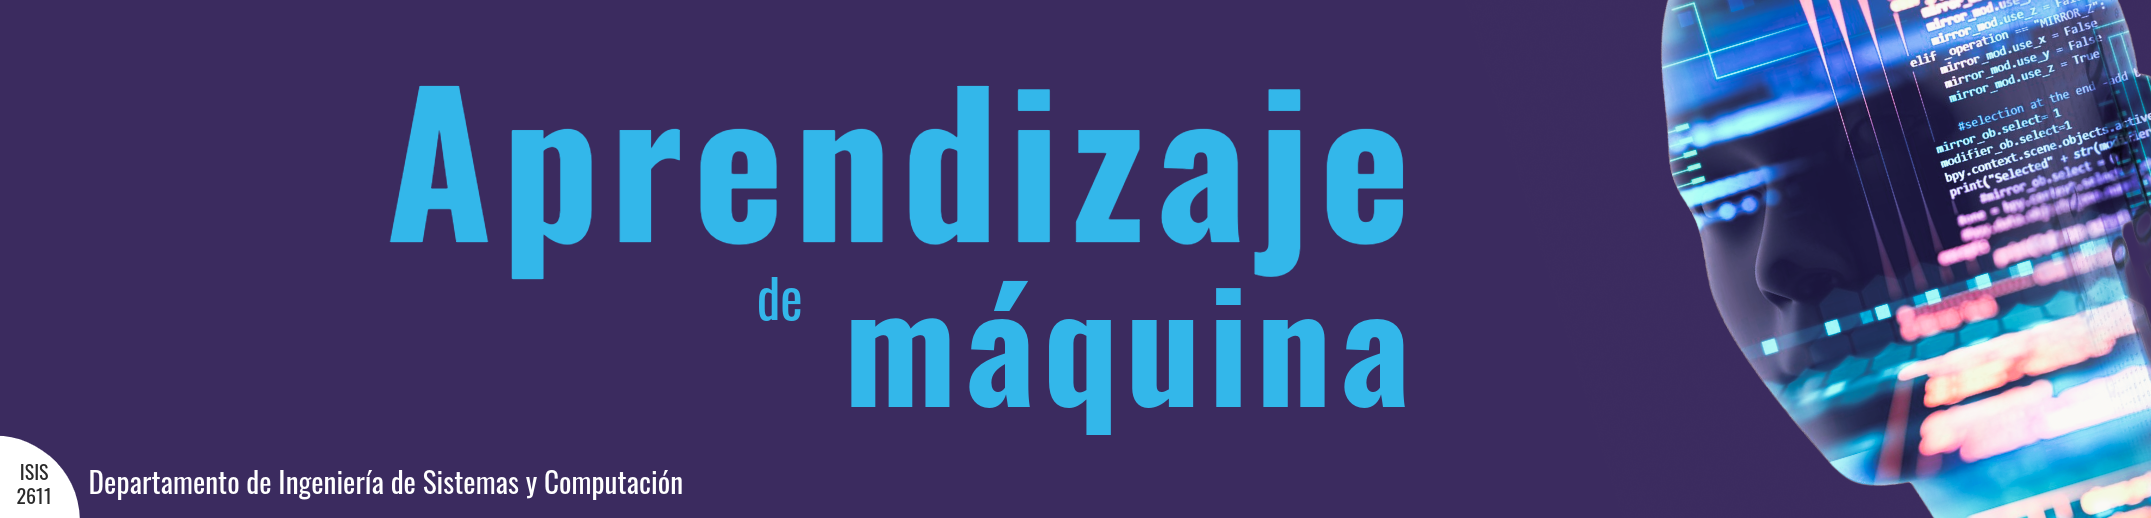

# Verificación de Supuestos de la Regresión Lineal

En este notebook aprenderás a verificar si el modelo de regresión lineal que hemos
construido sobre el dataset de inmuebles cumple con los supuestos estadísticos que
permiten interpretar sus coeficientes y confiar en sus pruebas de significancia.

> **Nota:** Este notebook asume que ya conoces el proceso de limpieza, transformación
> y entrenamiento del modelo trabajado en los notebooks anteriores.
> Aquí nos enfocamos únicamente en la verificación de supuestos.

El notebook se compone de las siguientes partes:

1. Importación de librerías. 
2. Carga y limpieza de datos. 
3. Partición y entrenamiento del modelo. 
4. Coeficientes del modelo.
5. Verificación de supuestos. 
6. Resumen y conclusiones. 
7. Ejercicios. 

## 1. Importación de librerías

Además de las librerías habituales de análisis, se incorporan herramientas
especializadas de `statsmodels` y `scipy` para las pruebas estadísticas de cada supuesto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

## 2. Carga y limpieza de datos

Reproducimos el pipeline de limpieza mínimo necesario: cargamos el dataset,
convertimos la columna `Fecha` y conservamos únicamente el registro más reciente
por cada `Id` (para eliminar duplicados lógicos).

In [2]:
datos_inmuebles = pd.read_excel('./data/Venta_Inmuebles.xlsx')

In [3]:
data = datos_inmuebles.copy()

In [4]:
data["Fecha"] = pd.to_datetime(data["Fecha"], errors="coerce")

# Ordenar por Id y Fecha
data = data.sort_values(["Id", "Fecha"])

# Para cada Id nos quedamos con el registro más reciente
data = data.drop_duplicates(subset="Id", keep="last")

In [5]:
# ids duplicados
dup_counts = (data['Id'].value_counts()
                        .loc[lambda s: s > 1]
                        .sort_values(ascending=False))
for id_, n in dup_counts.items():
    print(f"Id={id_} → {n} apariciones")

if dup_counts.sum() == 0:
    print("No hay duplicados")

No hay duplicados


## 3. Partición y entrenamiento del modelo

Dividimos los datos en conjuntos de entrenamiento y prueba, construimos el pipeline
de preprocesamiento idéntico al del notebook anterior y entrenamos el modelo de
regresión lineal sobre los datos de entrenamiento.

In [6]:
target = "Precio"
X = data.drop(columns=[target])
y = data[target]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=1)

### Pipeline de preprocesamiento

El pipeline aplica, en orden:
1. Eliminación de columnas no predictivas (`Id`, `Fecha`, `CodigoPostal`).
2. Corrección de la variable `Condición` (valores negativos y dígitos repetidos).
3. Normalización de `FrenteMar` a mayúsculas.
4. Imputación y escalado de variables numéricas.
5. Imputación y codificación one-hot de variables categóricas.

In [7]:
cols_to_drop = ["Id", "Fecha", "CodigoPostal"]

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors="ignore")

dropper = FunctionTransformer(drop_columns)

In [8]:
numeric_features = [
    "Cuartos", "Baños", "AreaHabitable", "AreaLote", "Pisos",
    "Vista", "Condición", "Calificación", "AreaSuperior",
    "AreaBase", "Años", "Renovación", "Latitud", "Longitud",
    "AreaHabitable15", "AreaLote15"
]

categorical_features = [
    "FrenteMar"
]

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

In [10]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

In [11]:
def limpiar_condicion(df):
    df = df.copy()
    df["Condición"] = df["Condición"].abs()
    df["Condición"] = df["Condición"].astype(str).str[0].astype(int)
    return df

limpieza_condicion = FunctionTransformer(limpiar_condicion)

In [12]:
def normalizar_frentemar(df):
    df = df.copy()
    df["FrenteMar"] = df["FrenteMar"].str.upper()
    return df

normalizar_frentemar_tr = FunctionTransformer(normalizar_frentemar)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [14]:
pipeline_regresion = Pipeline(steps=[
    ("dropper", dropper),
    ("limpiar_condicion", limpieza_condicion),
    ("normalizar_frentemar", normalizar_frentemar_tr),
    ("preprocesamiento", preprocessor),
    ("modelo", LinearRegression())
])

In [15]:
pipeline_regresion.fit(X_train, y_train)

,steps,"[('dropper', ...), ('limpiar_condicion', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function dro...002B6DE661440>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


### Predicciones y datos transformados

Generamos las predicciones sobre el conjunto de entrenamiento y extraemos
el DataFrame transformado que usaremos en las pruebas estadísticas.

In [16]:
y_train_pred = pipeline_regresion.predict(X_train)
Modelo = pipeline_regresion.named_steps['modelo']

Antes de entrar en los supuestos, dejamos registradas las métricas base del modelo sobre entrenamiento — las usaremos más adelante como referencia de comparación en los ejercicios.


In [17]:
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f'R²   train: {r2_train:.4f}')
print(f'RMSE train: {rmse_train:,.0f}')


R²   train: 0.6438
RMSE train: 216,384


In [18]:
# Obtener el DataFrame transformado (necesario para las pruebas estadísticas)
preprocesamiento = pipeline_regresion.named_steps['preprocesamiento']
X_train_dropped = dropper.transform(X_train)
X_train_cond = limpieza_condicion.transform(X_train_dropped)
X_train_fmar = normalizar_frentemar_tr.transform(X_train_cond)
Xt_train = preprocesamiento.transform(X_train_fmar)

feature_names_raw = preprocesamiento.get_feature_names_out()
feature_names_clean = [
    n.replace('num__', '').replace('cat__', '')
    for n in feature_names_raw
]

import scipy.sparse
if scipy.sparse.issparse(Xt_train):
    Xt_train = Xt_train.toarray()

Xt_train_df = pd.DataFrame(Xt_train, columns=feature_names_clean,
                            index=X_train.index)
print(f'Dataset transformado: {Xt_train_df.shape[0]} filas x {Xt_train_df.shape[1]} columnas')

Dataset transformado: 17148 filas x 17 columnas


## 4. Coeficientes del modelo

Antes de verificar los supuestos, revisamos los coeficientes que el modelo aprendió.
Los supuestos determinan si esos coeficientes pueden interpretarse de forma confiable.

Un modelo de regresión lineal tiene la forma:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_m x_m$$

donde $\beta_0$ es el intercepto y $\beta_1, \ldots, \beta_m$ son los coeficientes
de cada variable. Cada $\beta_i$ indica cuánto cambia el `Precio` estimado cuando
$x_i$ aumenta en una unidad, **manteniendo el resto de variables constantes**.

> Dado que aplicamos `StandardScaler`, todas las variables numéricas están en la misma
> escala, por lo que los coeficientes son directamente comparables entre sí en magnitud.

In [19]:
print("Intercepto:", Modelo.intercept_)

Intercepto: 535977.5250492493


In [20]:
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]
coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": Modelo.coef_
})
coef_df

,Variable,Coeficiente
0,Cuartos,-36897.762133
1,Baños,34407.196896
2,AreaHabitable,76403.794426
3,AreaLote,1626.451079
4,Pisos,16316.664310
5,Vista,18739.962961
6,Condición,12254.352394
7,Calificación,139939.069017
8,AreaSuperior,61397.249563
9,AreaBase,43109.387064


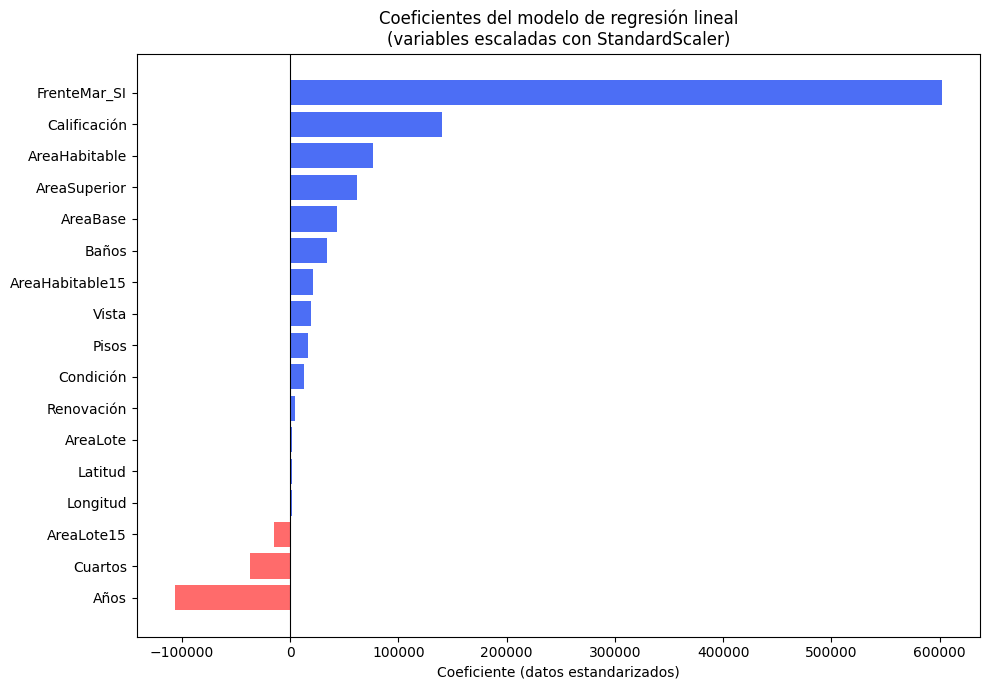

🔵 Azul = efecto positivo en el precio  |  🔴 Rojo = efecto negativo
   Recuerda: los coeficientes son comparables entre sí porque las variables están estandarizadas.


In [21]:
# Visualización de coeficientes ordenados
coef_sorted = coef_df.sort_values('Coeficiente')
colors = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in coef_sorted['Coeficiente']]

plt.figure(figsize=(10, 7))
plt.barh(coef_sorted['Variable'], coef_sorted['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (datos estandarizados)')
plt.title('Coeficientes del modelo de regresión lineal\n(variables escaladas con StandardScaler)')
plt.tight_layout()
plt.show()
print("🔵 Azul = efecto positivo en el precio  |  🔴 Rojo = efecto negativo")
print("   Recuerda: los coeficientes son comparables entre sí porque las variables están estandarizadas.")


Los coeficientes de la regresión lineal indican cuánto cambia, en promedio, el `Precio` cuando una variable independiente aumenta en una unidad, manteniendo las demás constantes. Un coeficiente positivo sugiere que el precio tiende a aumentar al incrementarse esa variable, mientras que un coeficiente negativo indica una relación inversa. La magnitud del coeficiente refleja la fuerza de ese efecto. El intercepto representa el valor del precio cuando todas las variables independientes son cero; aunque este escenario no sea realista, el intercepto es necesario desde el punto de vista estadístico para definir la recta de regresión.

Vemos que el coeficiente de `Cuartos`, `Años` o `AreaLote15` es negativo, eso sugiere que al aumentar esos valores el precio tiende a disminuir. En cambio, coeficientes positivos como los de `Calificación`, `FrenteMar_SI` o `AreaHabitable` indican que, al aumentar esas variables, el precio tiende a incrementarse, y mientras más grande sea el coeficiente, mayor es este efecto.

Es natural preguntarse para qué sirven los coeficientes, ya que el modelo puede generar predicciones sin necesidad de analizarlos explícitamente. Su principal utilidad reside en la interpretación, pues permiten comprender la dirección y la magnitud de la relación entre cada variable independiente y el precio. No obstante, esta interpretación solo es válida en la medida en que se cumplan los supuestos de la regresión lineal, los cuales deben verificarse para poder confiar en las conclusiones extraídas del modelo.

Antes de empezar con los supuestos, es importante que conozcamos algunos conceptos claves que nos ayudaran a entender esta sección mucho más:

+ **Error (o residual):** Es la diferencia entre el valor real y lo que el modelo predijo para una observación:

$$error=valor\;real−valor\;predicho$$

+ **Pruebas estadísticas y p-value:** Para verificar el cumplimiento de cada supuesto usamos una prueba estadística que devuelve un p-value. Ese p-value nos dice qué tan raro sería observar esos datos si el supuesto fuera cierto:

    * p-value grande (mayor a $0.05$): los datos no contradicen el supuesto, no tenemos motivos para rechazarlo.

    * p-value muy pequeño (menor a $0.05$): los datos sí se alejan claramente de lo que el supuesto dice, hay evidencia de que ese supuesto no se cumple.


#### ✏️ Ejercicio — interpretación de coeficientes

1. Según los coeficientes, ¿cuál variable tiene el mayor impacto positivo en el precio?
   ¿Tiene sentido desde el punto de vista del negocio inmobiliario?
2. `Cuartos` tiene coeficiente negativo. ¿Cómo se explica eso si intuitivamente
   más cuartos debería significar más precio?
3. ¿Por qué los coeficientes son comparables entre sí en este caso?
   ¿Qué habría pasado si no hubiéramos aplicado `StandardScaler`?

In [22]:
# Punto 1 — mayor impacto positivo
# La variable con mayor coeficiente positivo es... porque en el negocio inmobiliario...

# Punto 2 — Cuartos con coeficiente negativo
# Esto puede explicarse porque... (pista: piensa en correlaciones con otras variables)

# Punto 3 — por qué son comparables
# Los coeficientes son comparables porque StandardScaler...
# Sin StandardScaler, los coeficientes serían... porque...

## 5. Verificación de supuestos

### ¿Por qué verificar los supuestos?

La regresión lineal tiene cuatro supuestos principales que, si se cumplen, garantizan que:
1. Los **coeficientes** son los mejores estimadores lineales insesgados (teorema de Gauss-Markov).
2. Las **pruebas estadísticas** de significancia (prueba t, prueba F) son válidas.
3. Los **intervalos de confianza** de las predicciones son confiables.

> Si los supuestos **no** se cumplen, el modelo sigue produciendo predicciones,
> pero la interpretación de los coeficientes y las pruebas estadísticas pierden validez.

| Supuesto | ¿Qué verifica? | Prueba de diagnóstico |
|----------|--------------|----------------------|
| **No colinealidad** | Variables predictoras no correlacionadas entre sí | VIF |
| **Linealidad** | Relación lineal entre X e y | Test de Rainbow |
| **Normalidad de errores** | Los residuales siguen distribución normal | Shapiro-Wilk, Q-Q plot |
| **Homocedasticidad** | Varianza constante de los residuales | Breusch-Pagan |
| **Independencia de errores** | Los errores no están autocorrelacionados | Durbin-Watson |

Los analizaremos en el orden habitual de diagnóstico: primero los que afectan
la estructura del modelo (colinealidad, linealidad), luego los que afectan
los errores (normalidad, homocedasticidad, independencia).

### 5.1 Multicolinealidad

La multicolinealidad ocurre cuando dos o más variables independientes están altamente
correlacionadas entre sí. Aunque no impide al modelo hacer predicciones, sí hace que
los coeficientes individuales sean inestables: pequeños cambios en los datos pueden
producir cambios grandes en los coeficientes, y sus valores se vuelven difíciles de interpretar.

Se mide con el **Factor de Inflación de la Varianza (VIF)**:

- **VIF ≈ 1**: sin colinealidad con las demás variables.
- **VIF entre 5 y 10**: colinealidad moderada — revisar con cuidado.
- **VIF > 10**: colinealidad alta — los coeficientes son poco confiables.
- **VIF infinito**: colinealidad perfecta — la variable es combinación lineal exacta de otras.

In [23]:
X_vif = Xt_train_df.select_dtypes(include="number").copy()
clean_columns = (
    X_vif.columns
         .str.replace("^num__", "", regex=True)
         .str.replace("^cat__", "", regex=True)
)
vif_values = []
with np.errstate(divide="ignore", invalid="ignore"):
    for i in range(X_vif.shape[1]):
        vif = variance_inflation_factor(X_vif.values, i)
        vif_values.append(vif)

vif_data = pd.DataFrame({
    "Variable": clean_columns,
    "VIF": vif_values
})
print(vif_data)

           Variable       VIF
0           Cuartos  1.636423
1             Baños  3.331593
2     AreaHabitable       inf
3          AreaLote  2.027797
4             Pisos  1.937966
5             Vista  1.165529
6         Condición  1.229139
7      Calificación  3.176376
8      AreaSuperior       inf
9          AreaBase       inf
10             Años  1.997769
11       Renovación  1.145580
12          Latitud  1.000870
13         Longitud  1.001213
14  AreaHabitable15  2.802042
15       AreaLote15  2.067159
16     FrenteMar_SI  1.103457


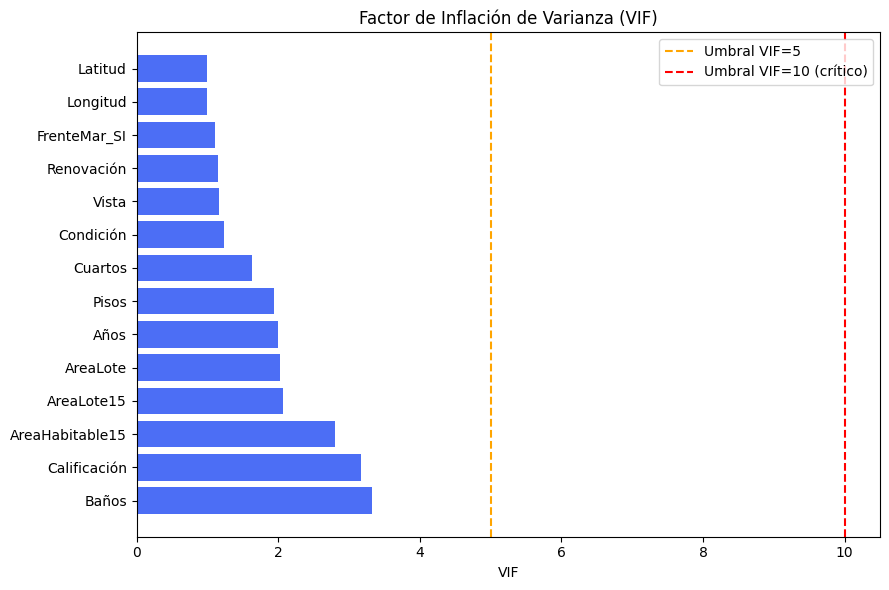

Variables con VIF infinito (multicolinealidad perfecta): ['AreaHabitable', 'AreaSuperior', 'AreaBase']
   Estas variables son combinación lineal exacta de otras — deberían eliminarse.


In [24]:
# Visualización del VIF
vif_finito = vif_data[np.isfinite(vif_data['VIF'])].sort_values('VIF', ascending=False)
vif_inf = vif_data[~np.isfinite(vif_data['VIF'])]

fig, ax = plt.subplots(figsize=(9, 6))
colors_vif = ['#FF6B6B' if v >= 5 else '#4C6EF5' for v in vif_finito['VIF']]
ax.barh(vif_finito['Variable'], vif_finito['VIF'], color=colors_vif)
ax.axvline(5, color='orange', linestyle='--', lw=1.5, label='Umbral VIF=5')
ax.axvline(10, color='red', linestyle='--', lw=1.5, label='Umbral VIF=10 (crítico)')
ax.set_xlabel('VIF')
ax.set_title('Factor de Inflación de Varianza (VIF)')
ax.legend()
plt.tight_layout()
plt.show()

if len(vif_inf) > 0:
    print(f"Variables con VIF infinito (multicolinealidad perfecta): {list(vif_inf['Variable'])}")
    print("   Estas variables son combinación lineal exacta de otras — deberían eliminarse.")


Los valores de VIF evidencian un problema de multicolinealidaden el modelo, específicamente en las variables `AreaHabitable`, `AreaSuperior` y `AreaBase`, que presentan valores infinitos, lo que indica una relación lineal perfecta entre ellas. Esta situación impide una estimación estable y confiable de sus coeficientes, afectando la interpretación del modelo, aunque no necesariamente su capacidad predictiva. El resto de las variables muestra valores de VIF bajos o moderados, lo que sugiere que la multicolinealidad está concentrada principalmente en las variables relacionadas con el área de la vivienda.


####  Ejercicio — multicolinealidad

1. ¿Cuáles son las variables con VIF infinito? ¿Qué relación matemática podría existir
   entre ellas? (Pista: piensa en cómo se relacionan `AreaSuperior`, `AreaBase` y `AreaHabitable`.)
2. Elimina `AreaSuperior` y `AreaBase` de `numeric_features` y vuelve a entrenar el modelo.
   ¿Cambian los VIF de las variables restantes? ¿Cambian las métricas?
3. ¿Por qué la multicolinealidad no afecta la capacidad predictiva del modelo
   pero sí afecta la interpretación de los coeficientes?

In [25]:
# Punto 1 — relación entre variables con VIF infinito
# AreaSuperior, AreaBase y AreaHabitable podrían relacionarse como...

# Punto 2 — eliminar variables colineales
# numeric_features_v2 = [col for col in numeric_features
#                        if col not in ['AreaSuperior', 'AreaBase']]
# (Re-ejecuta el pipeline con numeric_features_v2 y compara VIF y métricas)

# Punto 3 — reflexión
# La multicolinealidad no afecta las predicciones porque...
# Pero sí afecta los coeficientes porque...

### 5.2 Normalidad de los errores

Este supuesto establece que los residuales del modelo —la diferencia entre el valor real
y el predicho— deben seguir aproximadamente una distribución normal:

$$e_i = y_i - \hat{y}_i$$

Que la mayoría de los errores sean pequeños y los errores grandes sean
poco frecuentes y simétricamente distribuidos. Si se cumple, podemos hacer
pruebas t y F sobre los coeficientes y construir intervalos de confianza válidos.

**Herramientas de diagnóstico:**
- **Test Shapiro-Wilk**: p-value > 0.05 → no se rechaza normalidad.
- **Histograma de residuales**: debería parecerse a una campana simétrica.
- **Q-Q plot**: los puntos deben seguir la línea diagonal roja.

In [26]:
# Residuales en train
residuales = np.array(y_train - y_train_pred)

estat, p_shapiro = shapiro(residuales)
print("Shapiro-Wilk p-value:", p_shapiro)

Shapiro-Wilk p-value: 7.91879795957347e-86


D:\Anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 17148.
  res = hypotest_fun_out(*samples, **kwds)


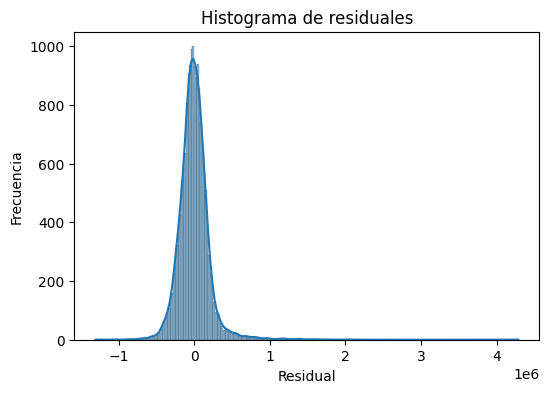

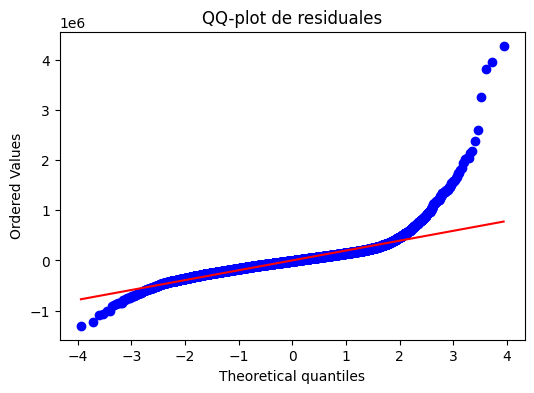

In [27]:
# Histograma
plt.figure(figsize=(6, 4))
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuales")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()

# 2. QQ-plot
plt.figure(figsize=(6, 4))
stats.probplot(residuales, dist="norm", plot=plt)
plt.title("QQ-plot de residuales")
plt.show()

#### Visualización interactiva: ¿qué es un Q-Q plot?

Un Q-Q plot compara los cuantiles de los residuales con los cuantiles esperados de una
distribución normal. Si los residuales fueran perfectamente normales, todos los puntos
caerían sobre la línea roja. Usa el widget siguiente para ver cómo luce un Q-Q plot
con distintos grados de sesgo, y luego compara con el Q-Q plot del modelo.

In [28]:
# Widget interactivo: visualizar cómo se ve un Q-Q plot con y sin normalidad
import ipywidgets as widgets
from IPython.display import display

def mostrar_qq_comparativo(skewness=0.0, n_puntos=500):
    np.random.seed(42)
    # Distribución controlada por el parámetro de sesgo
    datos_normales = np.random.normal(0, 1, n_puntos)
    from scipy.stats import skewnorm
    datos_sesgados = skewnorm.rvs(a=skewness * 5, size=n_puntos)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogramas
    axes[0].hist(datos_normales, bins=40, color='#4C6EF5', alpha=0.7, label='Normal')
    axes[0].hist(datos_sesgados, bins=40, color='#FF6B6B', alpha=0.7, label='Sesgada')
    axes[0].set_title('Distribuciones')
    axes[0].legend()

    # Q-Q plot distribución normal
    stats.probplot(datos_normales, dist='norm', plot=axes[1])
    axes[1].set_title('Distribución Normal (puntos sobre la línea = normalidad)')

    # Q-Q plot distribución sesgada
    stats.probplot(datos_sesgados, dist='norm', plot=axes[2])
    axes[2].set_title('Distribución Sesgada (puntos fuera de la línea = no normalidad)')

    plt.tight_layout()
    plt.show()

    _, p_normal  = shapiro(datos_normales[:200])
    _, p_sesgado = shapiro(datos_sesgados[:200])
    print(f"Shapiro-Wilk normal:  p = {p_normal:.4f}  {'Normal' if p_normal > 0.05 else 'No normal'}")
    print(f"Shapiro-Wilk sesgada: p = {p_sesgado:.4f}  {'Normal' if p_sesgado > 0.05 else 'No normal'}")

widgets.interact(
    mostrar_qq_comparativo,
    skewness=widgets.FloatSlider(value=0, min=0, max=3, step=0.5,
                                  description='Sesgo', continuous_update=False),
    n_puntos=widgets.IntSlider(value=500, min=100, max=1000, step=100,
                                description='N puntos', continuous_update=False)
)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Sesgo', max=3.0, step=0.5),…

<function __main__.mostrar_qq_comparativo(skewness=0.0, n_puntos=500)>


Obtuvimos con la prueba de Shapiro–Wilk un $p-value$ $≈$ $7.9×10⁻⁸⁶$, prácticamente cero. Eso significa que desde el punto de vista estadístico, los errores no siguen una distribución normal.
Las gráficas nos permiten comprobar eso, por un lado el histograma muestra que aunque la mayoría de los errores se concentran cerca de 0, hay una cola muy larga hacia valores positivos grandes. Y en el QQ-plot los puntos se alejan bastante de la línea recta en los extremos.
Estos resultados muestran que el supuesto de normalidad no se cumple en el modelo. Esto, como en el caso anterior, no anula el modelo, sino que nos dice que no podemos hacer pruebas estadísticas como la $t$ o $F$ ni obtener conclusiones sobre los coeficientes de la regresión.

> **Nota sobre el tamaño de muestra**: con cerca de 17.000 observaciones, el test de Shapiro-Wilk se vuelve extremadamente sensible — con tantos datos, casi cualquier desviación de la normalidad, por pequeña que sea en términos prácticos, produce un p-value diminuto. Por eso el histograma y el Q-Q plot importan tanto como el p-value: permiten juzgar si la desviación es grande y relevante (como aquí, con la cola larga hacia la derecha) o solo estadísticamente detectable por el tamaño de la muestra.


### 5.3 Homocedasticidad

Este supuesto establece que la varianza de los errores debe ser **constante**
para todos los niveles de las variables explicativas: el modelo debe equivocarse
con intensidad similar tanto en inmuebles de bajo precio como en los de alto precio.

Cuando no se cumple (heterocedasticidad), los errores estándar de los coeficientes
pueden estar mal estimados, haciendo que las pruebas t y F sean poco confiables.

Se verifica con la **prueba de Breusch-Pagan**: p-value < 0.05 indica heterocedasticidad.

In [29]:
X_num = Xt_train_df.select_dtypes(include="number").copy()
mask = np.isfinite(X_num).all(axis=1)
X_num_clean = X_num[mask]
resid_clean = residuales[mask]
X_num_const = sm.add_constant(X_num_clean)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid_clean, X_num_const)

print("Estadístico Breusch-Pagan:", bp_stat)
print("p-value Breusch-Pagan   :", bp_pvalue)

Estadístico Breusch-Pagan: 2098.5069673416892
p-value Breusch-Pagan   : 0.0



La prueba de Breusch–Pagan nos da un estadístico $≈ 1898.86$ y un p-value $= 0.0$. Esto significa que desde el punto de vista estadístico la varianza de los errores no es constante, lo que significa que el modelo se equivoca con distinta intensidad según el tipo de observación.

Este resultados nos dicen que debemos ser cuidadosos al interpretar las pruebas de significancia de los coeficientes, porque sus errores estándar podrían estar subestimados o sobreestimados, llevándonos a errores de interpretación.


### 5.4 Independencia de los errores

Este supuesto dice que el error cometido en una observación no debe influir
en el error de la siguiente. Si los errores están correlacionados entre sí
(autocorrelación), las pruebas estadísticas pierden fiabilidad.

Se evalúa con el **estadístico de Durbin-Watson**, que varía entre 0 y 4:

| Valor | Interpretación |
|-------|---------------|
| Cercano a 0 | Autocorrelación positiva (errores consecutivos van en el mismo sentido) |
| Cercano a 2 | Sin autocorrelación  |
| Cercano a 4 | Autocorrelación negativa (errores consecutivos van en sentidos opuestos) |

In [30]:
dw = durbin_watson(residuales)
print("Durbin-Watson:", dw)

Durbin-Watson: 2.0154662654201205



El estadístico de Durbin–Watson es $≈ 2.02$, un valor muy cercano a $2$. Esto indica que no se detecta autocorrelación entre los errores.Esto nos dice que los errores se comportan como ruido más o menos independiente entre observaciones. Por lo tanto, con este resultado podemos considerar que el supuesto de independencia de los errores sí se cumple en el modelo.


### 5.5 Linealidad

El supuesto de linealidad establece que la relación entre las variables explicativas
y la media de `Precio` puede describirse razonablemente mediante una combinación lineal:
cada variable aporta un efecto proporcional y constante sobre el precio cuando aumenta
en una unidad, manteniendo las demás fijas.

Se evalúa con el **test de Rainbow**, que parte el conjunto de entrenamiento en
subconjuntos y comprueba si el modelo lineal ajusta igual de bien en todos ellos.
Un p-value > 0.05 indica que no hay evidencia para rechazar la linealidad.

In [31]:
X_sm = sm.add_constant(Xt_train_df)
modelo_sm = sm.OLS(y_train, X_sm).fit()

rainbow_stat, rainbow_pvalue = linear_rainbow(modelo_sm)

print("Estadístico Rainbow:", rainbow_stat)
print("p-value Rainbow    :", rainbow_pvalue)

Estadístico Rainbow: 1.0254424118850194
p-value Rainbow    : 0.1225045057677485



Tenemos que el test de Rainbow dio un estadístico $≈ 1.03$ y un $p-value$ $≈ 0.12$. El p-value es mayor que el umbral de $0.05$, lo que significa que no hay evidencia estadística para rechazar la linealidad, la prueba considera razonable que la relación entre las variables explicativas y el precio pueda describirse mediante un modelo lineal. Por lo que según esa información el supuesto se cumple.


### 5.6 Diagnóstico visual: homocedasticidad e independencia

Las gráficas visuales complementan las pruebas estadísticas y permiten identificar
patrones que los tests no detectan directamente.

**Residuales vs Valores Ajustados** (homocedasticidad):
- Puntos distribuidos aleatoriamente alrededor de la línea cero → homocedasticidad.
- Patrón de embudo (dispersión crece con el precio) → heterocedasticidad.

**Residuales vs Índice** (independencia):
- Puntos sin tendencia → errores independientes.
- Patrones cíclicos o tendencia creciente → autocorrelación.

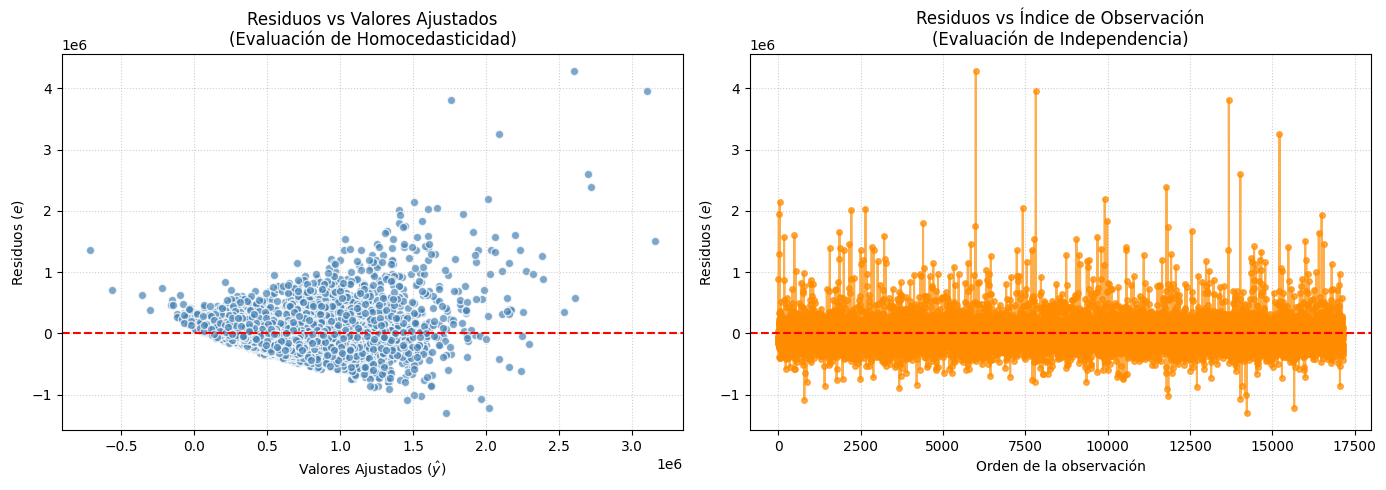

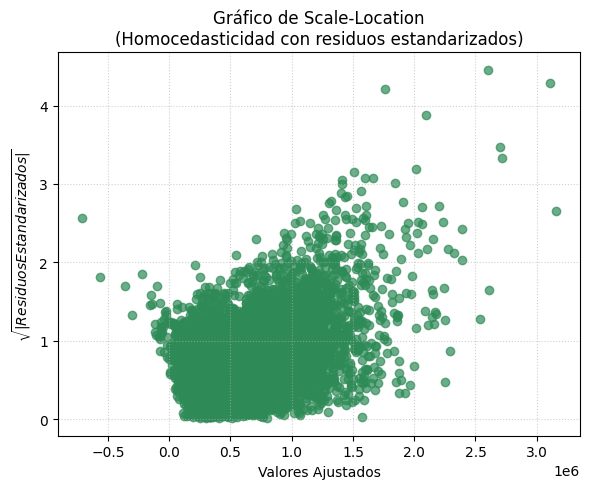

In [32]:
# Gráficas para ver de manera visual la homocedasticidad e independencia de los residuos

nombres_x = " + ".join(Xt_train_df.columns)

df_graficas=Xt_train_df.join(y_train)

# 2. Fit the linear regression model
model = ols(f'Precio ~ {nombres_x}', data=df_graficas).fit()
fitted_values = model.fittedvalues
residuals = model.resid

# Generación de las gráficas
plt.figure(figsize=(14, 5))

# Gráfica de Homocedasticidad
plt.subplot(1, 2, 1)
plt.scatter(fitted_values, residuals, alpha=0.7, color='steelblue', edgecolors='white')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs Valores Ajustados\n(Evaluación de Homocedasticidad)')
plt.xlabel(r'Valores Ajustados ($\hat{y}$)')
plt.ylabel('Residuos ($e$)')
plt.grid(True, linestyle=':', alpha=0.6)

# Gráfica de Independencia
plt.subplot(1, 2, 2)
plt.plot(range(len(residuals)), residuals, marker='o', linestyle='-', markersize=4, alpha=0.7, color='darkorange')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs Índice de Observación\n(Evaluación de Independencia)')
plt.xlabel('Orden de la observación')
plt.ylabel('Residuos ($e$)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
# plt.savefig('evaluacion_regresion.png')

# Scale-Location plot (optional but very useful for homoscedasticity)
plt.figure(figsize=(6, 5))
standardized_residuals = model.get_influence().resid_studentized_internal
plt.scatter(fitted_values, np.sqrt(np.abs(standardized_residuals)), alpha=0.7, color='seagreen')
plt.title('Gráfico de Scale-Location\n(Homocedasticidad con residuos estandarizados)')
plt.xlabel('Valores Ajustados')
plt.ylabel(r'$\sqrt{|Residuos Estandarizados|}$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
# plt.savefig('scale_location.png')

#### Interpretación de los gráficos

**Gráfico de Residuales vs Valores Ajustados** (homocedasticidad):
- Si los puntos se distribuyen aleatoriamente alrededor de la línea cero sin patrón →  homocedasticidad.
- Si los puntos forman un "embudo" (mayor dispersión a mayor precio) →  heterocedasticidad.

**Gráfico de Residuales vs Índice** (independencia):
- Si los puntos varían aleatoriamente sin tendencia →  independencia.
- Si hay patrones cíclicos o tendencias →  autocorrelación.

## 6. Resumen y conclusiones

La siguiente tabla consolida el resultado de cada prueba y su impacto sobre la
interpretabilidad del modelo.

In [33]:
# Resumen de supuestos
resumen_supuestos = pd.DataFrame({
    'Supuesto': ['No colinealidad', 'Normalidad de errores',
                 'Homocedasticidad', 'Independencia de errores', 'Linealidad'],
    'Prueba': ['VIF', 'Shapiro-Wilk', 'Breusch-Pagan', 'Durbin-Watson', 'Rainbow'],
    'Resultado': ['VIF infinito en algunas vars', f'p={p_shapiro:.2e}', f'p={bp_pvalue:.4f}',
                  f'DW={dw:.3f}', f'p={rainbow_pvalue:.3f}'],
    'Se cumple': [' No (multicolinealidad perfecta)', ' No (p < 0.05)',
                  ' No (p < 0.05)', ' Sí (DW ≈ 2)', ' Sí (p > 0.05)'],
    'Impacto': ['Coeficientes inestables', 'Pruebas t/F no válidas',
                'Errores estándar sesgados', 'Sin impacto', 'Sin impacto']
})
print(resumen_supuestos.to_string(index=False))

                Supuesto        Prueba                    Resultado                        Se cumple                   Impacto
         No colinealidad           VIF VIF infinito en algunas vars  No (multicolinealidad perfecta)   Coeficientes inestables
   Normalidad de errores  Shapiro-Wilk                   p=7.92e-86                    No (p < 0.05)    Pruebas t/F no válidas
        Homocedasticidad Breusch-Pagan                     p=0.0000                    No (p < 0.05) Errores estándar sesgados
Independencia de errores Durbin-Watson                     DW=2.015                      Sí (DW ≈ 2)               Sin impacto
              Linealidad       Rainbow                      p=0.123                    Sí (p > 0.05)               Sin impacto


### ¿Qué implica este diagnóstico?

El modelo **sí puede usarse para predecir precios** — sus métricas de precisión
(RMSE, R²) no se ven afectadas por el incumplimiento de los supuestos.

Lo que **no podemos hacer** de forma confiable con este modelo:
- Interpretar los coeficientes individuales como efectos causales.
- Afirmar que una variable es 'estadísticamente significativa' usando la prueba t.
- Construir intervalos de confianza exactos para las predicciones.

**Próximos pasos posibles para mejorar el modelo:**
1. Eliminar variables con multicolinealidad perfecta (`AreaSuperior`, `AreaBase`).
2. Aplicar transformación logarítmica al precio para reducir la heterocedasticidad
   y la asimetría de los errores.
3. Explorar modelos regularizados (Ridge, Lasso) que son más robustos
   a la multicolinealidad.

## 7. Ejercicios

### Ejercicio 1 — Eliminar variables colineales

Elimina las variables con VIF infinito (`AreaSuperior` y `AreaBase`) y observa
el efecto en los VIF restantes y en las métricas del modelo.

Después de ejecutar el código scaffold:
- ¿Desaparecen los VIF infinitos?
- ¿Cambian las métricas (RMSE, R²)?
- ¿Cambian los coeficientes de las variables restantes? ¿Por qué?

In [34]:
# Ejercicio 1: eliminar variables con multicolinealidad perfecta
numeric_features_sin_colin = [f for f in numeric_features
                               if f not in ['AreaSuperior', 'AreaBase']]

preprocessor_sc = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features_sin_colin),
    ("cat", categorical_transformer, categorical_features),
])

pipeline_sc = Pipeline(steps=[
    ("dropper", dropper), ("limpiar_condicion", limpieza_condicion),
    ("normalizar_frentemar", normalizar_frentemar_tr),
    ("preprocesamiento", preprocessor_sc),
])

Xt_sc = pipeline_sc.fit_transform(X_train)
fn_sc = pipeline_sc.named_steps["preprocesamiento"].get_feature_names_out()
Xt_sc_df = pd.DataFrame(Xt_sc.toarray() if hasattr(Xt_sc,"toarray") else Xt_sc,
                          columns=fn_sc, index=X_train.index)

modelo_sc = LinearRegression().fit(Xt_sc_df, y_train)
ytr_sc = modelo_sc.predict(Xt_sc_df)

print("=== Sin AreaSuperior y AreaBase ===")
print(f"R² train: {r2_score(y_train, ytr_sc):.4f}  |  RMSE: {np.sqrt(mean_squared_error(y_train, ytr_sc)):,.0f}")
print(f"=== Modelo original ===")
print(f"R² train: {r2_train:.4f}  |  RMSE: {rmse_train:,.0f}")

# VIF del modelo sin colinealidad
X_vif2 = Xt_sc_df.copy()
vif2 = pd.DataFrame({
    "Variable": X_vif2.columns.str.replace("num__","").str.replace("cat__",""),
    "VIF": [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])]
})
print("=== VIF sin variables colineales ===")
print(vif2[vif2['VIF'] != np.inf].sort_values('VIF', ascending=False).to_string(index=False))

=== Sin AreaSuperior y AreaBase ===
R² train: 0.6434  |  RMSE: 216,513
=== Modelo original ===
R² train: 0.6438  |  RMSE: 216,384
=== VIF sin variables colineales ===
       Variable      VIF
  AreaHabitable 5.021493
          Baños 3.231197
   Calificación 3.151402
AreaHabitable15 2.708230
     AreaLote15 2.063317
       AreaLote 2.022740
           Años 1.972900
        Cuartos 1.636182
          Pisos 1.593212
      Condición 1.223839
          Vista 1.146257
     Renovación 1.145460
   FrenteMar_SI 1.103436
       Longitud 1.001174
        Latitud 1.000843


### Ejercicio 2 — Transformación logarítmica

Una estrategia común para reducir la heterocedasticidad y la asimetría de los errores
en modelos de precios es predecir el **logaritmo del precio** en lugar del precio directo.

1. Crea una nueva variable `log_Precio = np.log(y)` y úsala como objetivo.
2. Entrena el mismo pipeline con el nuevo objetivo.
3. Vuelve a ejecutar las pruebas de Shapiro-Wilk y Breusch-Pagan.
4. ¿Mejoran los supuestos? ¿A qué costo en términos de interpretabilidad?

D:\Anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 17148.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk (log precio): p = 1.56e-12
Shapiro-Wilk (precio orig): p = 7.92e-86


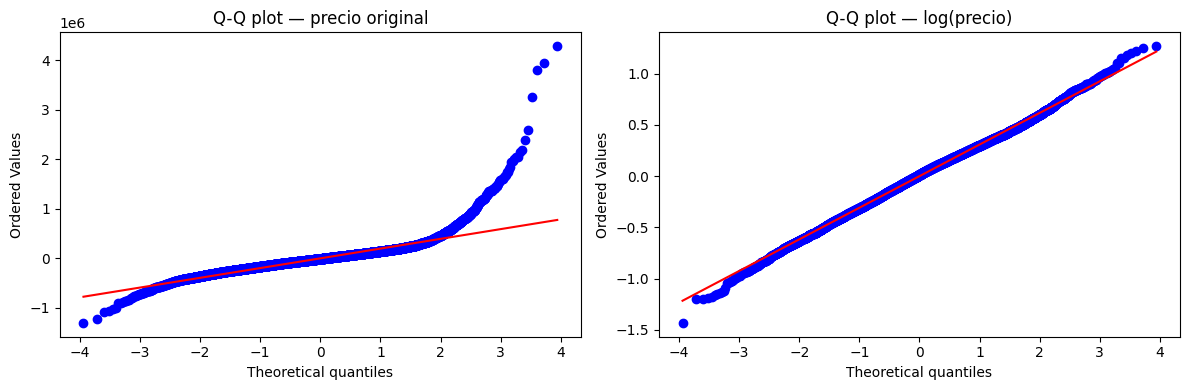

In [35]:
# Scaffold Ejercicio 2: transformación logarítmica
log_y_train = np.log(y_train)
log_y_test  = np.log(y_test)

pipeline_log = Pipeline(steps=[
    ('dropper', dropper),
    ('limpiar_condicion', limpieza_condicion),
    ('normalizar_frentemar', normalizar_frentemar_tr),
    ('preprocesamiento', preprocessor),
    ('modelo', LinearRegression())
])
pipeline_log.fit(X_train, log_y_train)
log_y_train_pred = pipeline_log.predict(X_train)

# Residuales sobre log(precio)
residuales_log = log_y_train - log_y_train_pred

_, p_shapiro_log = shapiro(residuales_log)
print(f'Shapiro-Wilk (log precio): p = {p_shapiro_log:.2e}')
print(f'Shapiro-Wilk (precio orig): p = {p_shapiro:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuales,     dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot — precio original')
stats.probplot(residuales_log, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot — log(precio)')
plt.tight_layout()
plt.show()

# ¿Mejora el supuesto de normalidad? ¿Y el de homocedasticidad?
# Responde como comentario:

### Ejercicio 3 — Modelo final integrador

Construye la mejor versión del modelo que puedas combinando lo aprendido:
1. Elimina las variables con multicolinealidad perfecta.
2. Aplica transformación logarítmica al precio.
3. Compara las métricas finales con el modelo original.
4. Verifica si los supuestos mejoran con ambas correcciones.

¿Es posible que un modelo con mejores supuestos tenga peores métricas (RMSE, R²)?
¿Cómo resolverías esa tensión?

In [36]:
# Ejercicio 3 — construye tu mejor modelo
# Pista: parte del pipeline_sc del ejercicio 1 y ajústalo

# Tu pipeline mejorado:
# pipeline_mejorado = Pipeline(steps=[...])

# Entrena y evalúa:
# ...

# Compara en tabla:
# | Modelo         | R² train | R² test | RMSE train | RMSE test |
# |----------------|----------|---------|------------|-----------|
# | Original       | ...      | ...     | ...        | ...       |
# | Sin colineales | ...      | ...     | ...        | ...       |
# | Tuyo mejorado  | ...      | ...     | ...        | ...       |

print("Implementa tu modelo mejorado aquí.")

Implementa tu modelo mejorado aquí.


## Cierre

En este notebook verificamos los cinco supuestos clásicos de la regresión lineal sobre el modelo de precios de inmuebles:

| Supuesto | ¿Se cumple? | Consecuencia si se ignora |
|----------|-------------|---------------------------|
| No colinealidad | No — VIF infinito en `AreaHabitable`, `AreaSuperior`, `AreaBase` | Coeficientes inestables e imposibles de interpretar individualmente |
| Normalidad de errores | No — Shapiro-Wilk p ≈ 7.9×10⁻⁸⁶ | Las pruebas t/F sobre los coeficientes no son válidas |
| Homocedasticidad | No — Breusch-Pagan p ≈ 0 | Los errores estándar pueden estar mal estimados |
| Independencia de errores | Sí — Durbin-Watson ≈ 2.02 | — |
| Linealidad | Sí — Rainbow p ≈ 0.12 | — |

El resultado más importante de este notebook no es la lista de supuestos que fallan, sino la distinción entre **predecir** y **explicar**: el modelo sigue siendo útil para estimar precios (sus métricas de error no cambian por incumplir supuestos), pero no podemos confiar en sus coeficientes individuales como si fueran efectos causales validados estadísticamente. En datos reales esto es la norma, no la excepción, ya que rara vez se cumplen todos los supuestos a la vez, y parte del trabajo del analista es decidir cuánto le importa cada violación según el objetivo del modelo.

Los ejercicios exploran dos caminos concretos para mejorar la situación sin cambiar de algoritmo: eliminar variables perfectamente colineales y transformar la variable objetivo (`log(Precio)`). Si esas correcciones no bastan, el siguiente paso natural, fuera del alcance de este notebook, es explorar modelos regularizados (Ridge, Lasso), que son más robustos a la multicolinealidad, o revisar si una relación no lineal describe mejor los datos.
